# PDAS CA2
# What job industries offer the highest salary and best stability?
This study examines which job industries in Singapore provide the most attractive combination of high salary and strong employment stability. As individual job preferences are not directly observable in employment datasets, gross monthly income is used as a proxy for salary attractiveness, while employment stability is represented by indicators such as overall employment rate and full-time permanent employment rate.

By analysing trends across major industry groups `Construction, Manufacturing, Services, and Others` and over multiple years, this study aims to identify industries that offer favourable trade-offs between income levels and job security. The findings are intended to support individuals in making more informed career decisions by highlighting industries that balance financial rewards with long-term employment stability.



In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV files ```````````````````````````````````````````````````````````````````````````
ge1 = pd.read_csv("(1) graduate employment survey modified.csv") 
ge2 = pd.read_csv("(2) graduate employment survey modified .csv") 
print("ge1")
ge1.info()
print("ge2")
ge2.info()


ge1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        5135 non-null   object
 1   university  5135 non-null   object
 2   school      5135 non-null   object
 3   degree      5135 non-null   object
 4   Key         5135 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 200.7+ KB
ge2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employment_rate_overall      5027 non-null   object 
 1   employment_rate_ft_perm      5027 non-null   object 
 2   basic_monthly_mean           5027 non-null   object 
 3   basic_monthly_median         5027 non-null   object 
 4   gross_monthly_mean           5027 non-null   object 
 5   gross_monthly_median         5027 no

In [13]:
ge1.head()

,year,university,school,degree,Key
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5


In [14]:
ge2.head()

,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


In [ ]:
# Merge datasets 
df = pd.merge(ge1, ge2, on = "Key", how="inner")
df = df.loc[:, ~df.columns.str.contains("Unnamed", case=False)]

# Save cleaned dataset
df.to_csv("ge_merged.csv", index=False)

In [16]:
final_df = df.copy()
final_df.info()
final_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   year                         5135 non-null   object
 1   university                   5135 non-null   object
 2   school                       5135 non-null   object
 3   degree                       5135 non-null   object
 4   Key                          5135 non-null   int64 
 5   employment_rate_overall      5027 non-null   object
 6   employment_rate_ft_perm      5027 non-null   object
 7   basic_monthly_mean           5027 non-null   object
 8   basic_monthly_median         5027 non-null   object
 9   gross_monthly_mean           5027 non-null   object
 10  gross_monthly_median         5027 non-null   object
 11  gross_mthly_25_percentile    5027 non-null   object
 12  gross_mthly_75_percentile    5027 non-null   object
 13  gross_monthly_mean.1         5027

,year,university,school,degree,Key,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,gross_mthly_25_percentile.1,gross_mthly_75_percentile.1
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,2700,3500
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,3000,4100
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,3100,3816


In [17]:
# Cleaning Graduate Employment
# Check for duplicates
duplicate_count = final_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if any
if duplicate_count > 0:
    final_df = final_df.drop_duplicates()
    print("Duplicates removed. New shape:", final_df.shape)
else:
    print("No duplicate rows found.")

# Check for duplicated columns (by values)
duplicate_col_count = final_df.T.duplicated().sum()
print("Number of duplicate columns:", duplicate_col_count)

# Remove duplicated columns 
df = final_df.loc[:, ~final_df.T.duplicated()]

print("New shape after dropping duplicate columns:", df.info())  

Number of duplicate rows: 0
No duplicate rows found.
Number of duplicate columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       5135 non-null   object
 1   university                 5135 non-null   object
 2   school                     5135 non-null   object
 3   degree                     5135 non-null   object
 4   Key                        5135 non-null   int64 
 5   employment_rate_overall    5027 non-null   object
 6   employment_rate_ft_perm    5027 non-null   object
 7   basic_monthly_mean         5027 non-null   object
 8   basic_monthly_median       5027 non-null   object
 9   gross_monthly_mean         5027 non-null   object
 10  gross_monthly_median       5027 non-null   object
 11  gross_mthly_25_percentile  5027 non-null   object
 12  gross_mthly_75_percentile  5027 no

In [18]:
# Check for missing values
print("--- Empty values ---")
print(df.isna().sum())

# Drop completely empty rows
df = df.dropna()

print("--- After Dropping ---")
print(df.isna().sum())

--- Empty values ---
year                           0
university                     0
school                         0
degree                         0
Key                            0
employment_rate_overall      108
employment_rate_ft_perm      108
basic_monthly_mean           108
basic_monthly_median         108
gross_monthly_mean           108
gross_monthly_median         108
gross_mthly_25_percentile    108
gross_mthly_75_percentile    108
dtype: int64
--- After Dropping ---
year                         0
university                   0
school                       0
degree                       0
Key                          0
employment_rate_overall      0
employment_rate_ft_perm      0
basic_monthly_mean           0
basic_monthly_median         0
gross_monthly_mean           0
gross_monthly_median         0
gross_mthly_25_percentile    0
gross_mthly_75_percentile    0
dtype: int64


In [2]:
income_df = pd.read_csv("FT_Res_ind_income.csv")
income_df.info()
print(income_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   year                                                384 non-null    object
 1   industry                                            384 non-null    object
 2   median_gross_monthly_income_including_employer_cpf  384 non-null    int64 
 3   median_gross_monthly_income_excluding_employer_cpf  384 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 12.1+ KB
year                                                  0
industry                                              0
median_gross_monthly_income_including_employer_cpf    0
median_gross_monthly_income_excluding_employer_cpf    0
dtype: int64


In [4]:
# 1. Convert the 'year' column to numeric
# 'errors=coerce' will turn any non-numeric text into NaN (null)
income_df['year_numeric'] = pd.to_numeric(income_df['year'], errors='coerce')

# 2. Filter the DataFrame for the years 2020 to 2024
# Using .copy() ensures the new df is an independent object
income24df = income_df[(income_df['year_numeric'] >= 2015) & (income_df['year_numeric'] <= 2024)].copy()

# 3. Remove the helper numeric column and reset the index
income24df = income24df.drop(columns=['year_numeric']).reset_index(drop=True)

# Verify the result
print(income24df['year'].unique())
print(income24df.head())
print(income24df.info())
print(income24df['industry'].head())

['2015' '2016' '2017' '2018' '2019' '2020' '2021' '2022' '2023' '2024']
   year                  industry  \
0  2015             manufacturing   
1  2015              construction   
2  2015                  services   
3  2015  wholesale & retail trade   
4  2015  transportation & storage   

   median_gross_monthly_income_including_employer_cpf  \
0                                               4437    
1                                               3790    
2                                               3844    
3                                               3549    
4                                               2916    

   median_gross_monthly_income_excluding_employer_cpf  
0                                               3792   
1                                               3300   
2                                               3375   
3                                               3186   
4                                               2511   
<class 'pandas.core.frame.

### 1. Distribution of salary
Observe if the salaries are bell-shaped and leaning towards the right or left as well as the most common salaries by count

In [5]:
# 1. Define the list of industries you want to keep
target_industries = ["manufacturing", "construction", "services", "others"]

# 2. Filter the dataframe to only include rows where 'industry' matches one of those 4
# We use .copy() to make it a standalone dataframe for your analysis
income24df = income24df[income24df['industry'].isin(target_industries)].copy()

# 3. If you want to put these into a brand new column (leaving the old one as is)
income24df['new_industry'] = income24df['industry']

# Verify the result
print(income24df['new_industry'].unique())
print(f"Number of rows kept: {len(income24df)}")
# View the first 5 full rows
print(income24df.info())

['manufacturing' 'construction' 'services' 'others']
Number of rows kept: 40
<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 159
Data columns (total 5 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   year                                                40 non-null     object
 1   industry                                            40 non-null     object
 2   median_gross_monthly_income_including_employer_cpf  40 non-null     int64 
 3   median_gross_monthly_income_excluding_employer_cpf  40 non-null     int64 
 4   new_industry                                        40 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.9+ KB
None


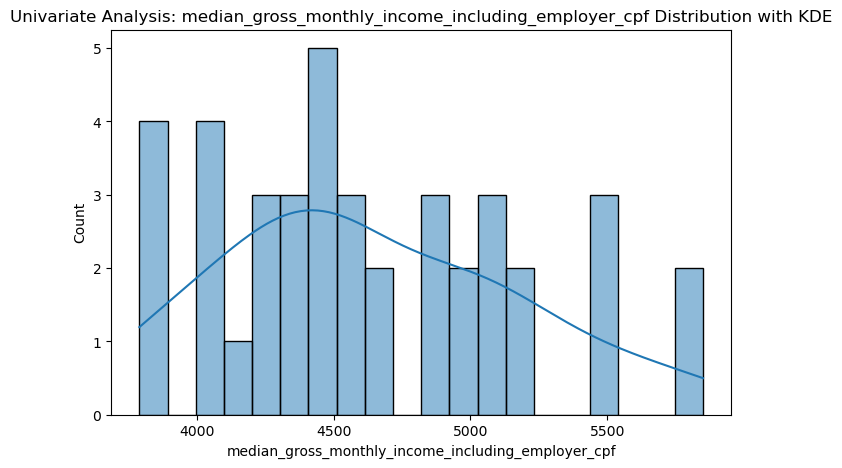

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(income24df["median_gross_monthly_income_including_employer_cpf"], kde=True, bins=20)
plt.title("Univariate Analysis: median_gross_monthly_income_including_employer_cpf Distribution with KDE")
plt.show()

### 2. Stability Differences between Job Industries
How do median gross monthly incomes differ across job sectors for job seekers in Singapore, and which sectors consistently offer higher salaries over time?

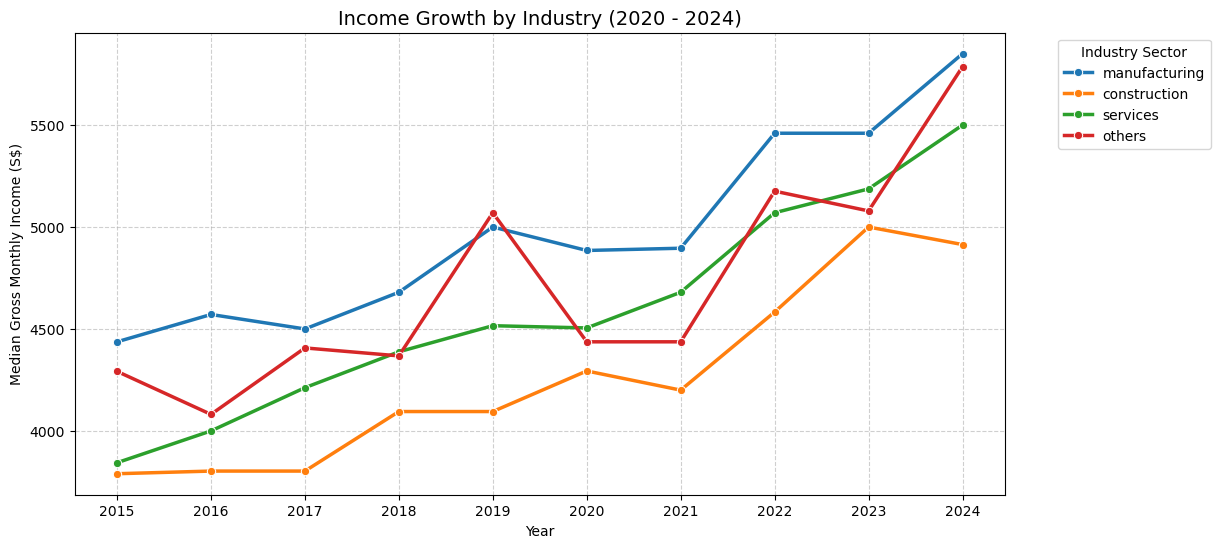

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=income24df, x='year', y='median_gross_monthly_income_including_employer_cpf', 
             hue='industry', marker='o', linewidth=2.5)

plt.title('Income Growth by Industry (2020 - 2024)', fontsize=14)
plt.ylabel('Median Gross Monthly Income (S$)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()